# 05 - Model 3 (final): fixed 2009-2023 window, comparisons, Model 3b and checks

* **Model 3**: the proposal predictors (8 climate features + spring type), VIF screening fitted on
  training springs only, Random Forest (2,000 trees, balanced class weights), stratified 70/30 split,
  shuffled 5-fold CV, and a leave-one-grid-cell-out ("new area") test.
* **Comparisons**: spring type only, climate only.
* **Model 3b**: label screening by the survey's reported cause - drought-dried vs active springs, with
  earthquake-dried vs active as a contrast.
* **Checks**: number of distinct feature rows, a lookup-table baseline, the effect of unshuffled CV,
  and the Version A leakage diagnostic (window end year as the only input).

In [1]:
import sys, json, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))  # run from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from spring_drying.config import (FIGURES_DIR, TABLES_DIR, RANDOM_STATE, WINDOW_END, WINDOW_LEN,
                                  SURVEY_YEAR, ERA5_LAND_FIRST_YEAR, RAW_SURVEY_PATH, NC_PATH)
from spring_drying.data import load_springs, attach_drying_reason

sns.set_style("whitegrid")
pd.set_option("display.width", 140)

def save_json(obj, name):
    def conv(o):
        if isinstance(o, (np.integer,)): return int(o)
        if isinstance(o, (np.floating,)): return float(o)
        if isinstance(o, (np.ndarray,)): return o.tolist()
        raise TypeError(type(o))
    with open(TABLES_DIR / name, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, default=conv)
    print("saved", TABLES_DIR / name)

from spring_drying.climate import FEATURE_COLS
from spring_drying.modeling import make_rf, make_model3
from spring_drying.experiments import run_experiment, print_result

springs = load_springs()
base = springs.drop(columns=FEATURE_COLS + ["Perennial / Seasonal"])  # CSV climate columns unused; text label replaced by 0/1
ASPECT = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
ROADS = [f"Road-{a}" for a in ASPECT]
ASPECT_1HOT = [f"Aspect-{a}" for a in ASPECT]

In [2]:
from spring_drying.climate import grid_cell_ids

springs = attach_drying_reason(springs)
version_b = pd.read_csv(TABLES_DIR / "climate_features_version_b.csv")
data = pd.concat([springs[["dried", "drying_reason", "perennial", "dried_year"]].reset_index(drop=True), version_b], axis=1)
data = data.rename(columns={"perennial": "Perennial / Seasonal"})
groups = grid_cell_ids(springs["Latitude"].values, springs["Longitude"].values)
FEATURES = FEATURE_COLS + ["Perennial / Seasonal"]
X, y = data[FEATURES], data["dried"].values
print("springs", len(X), "| climate grid cells", len(set(groups)),
      "| distinct feature rows", X.round(9).drop_duplicates().shape[0])

springs 3287 | climate grid cells 12 | distinct feature rows 23


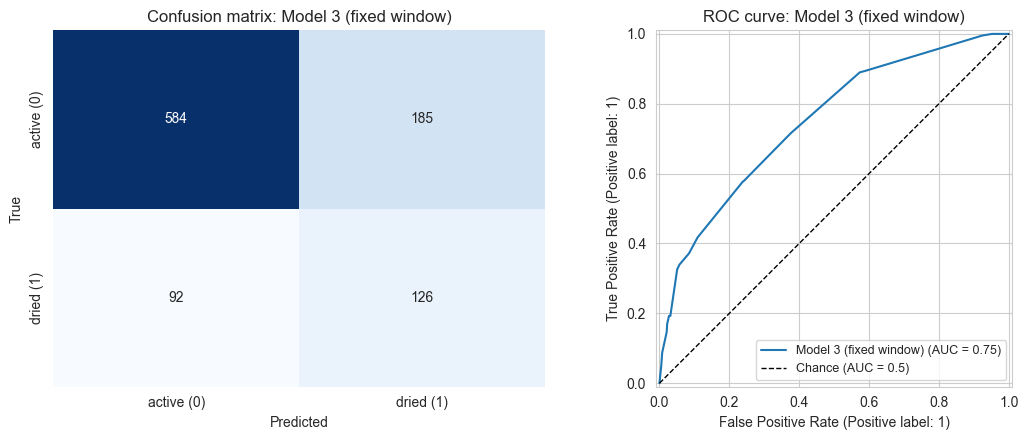

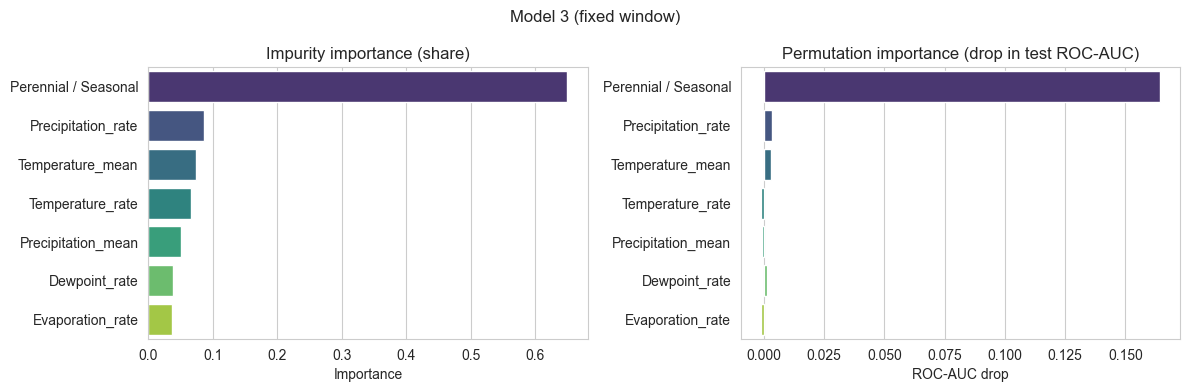

Model 3 (fixed window)  (n = 3287, dried = 727, test = 987)
  test: accuracy 0.719, precision 0.405, recall 0.578, f1 0.476, roc_auc 0.748
  confusion: TN 584  FP 185  FN 92  TP 126
  5-fold CV (shuffled): F1 0.511 +/- 0.023, AUC 0.760 +/- 0.011
  new-area (leave-one-grid-cell-out) AUC 0.630
  VIF dropped: [['Dewpoint_mean', 938.59], ['Evaporation_mean', 75.62]]


,impurity,permutation
Perennial / Seasonal,0.6491,0.1643
Precipitation_rate,0.0861,0.0033
Temperature_mean,0.0737,0.0028
Temperature_rate,0.0655,-0.0010
Precipitation_mean,0.0503,-0.0007
Dewpoint_rate,0.0390,0.0013
Evaporation_rate,0.0363,-0.0013


In [3]:
model3, fitted3 = run_experiment("model3_final", "Model 3 (fixed window)", X, y, make_model3(),
                                 groups=groups, new_area=True)
print_result(model3)
pd.DataFrame({"impurity": model3["importance_impurity"], "permutation": model3["importance_permutation"]}).round(4)

## Comparisons and Model 3b (label screening by drying cause)

Spring type only  (n = 3287, dried = 727, test = 987)
  test: accuracy 0.799, precision 0.568, recall 0.385, f1 0.459, roc_auc 0.651
  confusion: TN 705  FP 64  FN 134  TP 84
  5-fold CV (shuffled): F1 0.480 +/- 0.020, AUC 0.662 +/- 0.011
  new-area (leave-one-grid-cell-out) AUC 0.584
  VIF dropped: []


Climate only  (n = 3287, dried = 727, test = 987)
  test: accuracy 0.621, precision 0.293, recall 0.505, f1 0.370, roc_auc 0.625
  confusion: TN 503  FP 266  FN 108  TP 110
  5-fold CV (shuffled): F1 0.401 +/- 0.023, AUC 0.637 +/- 0.025
  new-area (leave-one-grid-cell-out) AUC 0.527
  VIF dropped: [['Dewpoint_mean', 938.59], ['Evaporation_mean', 75.62]]


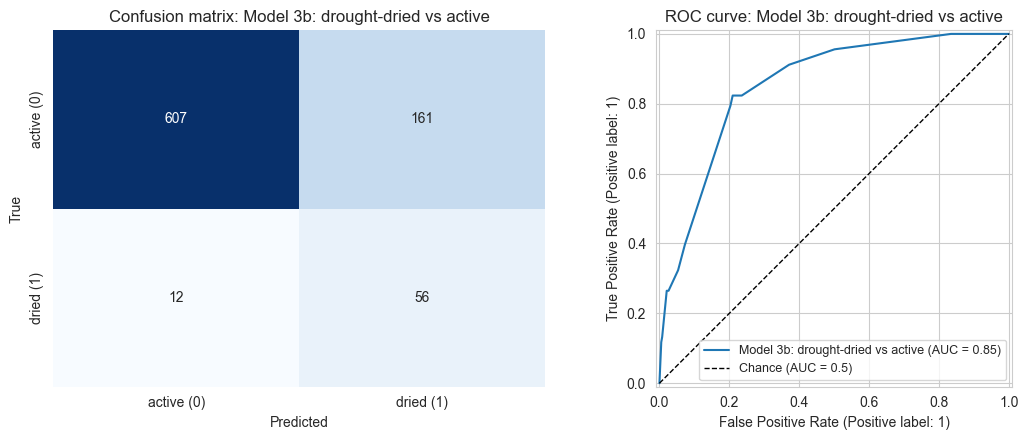

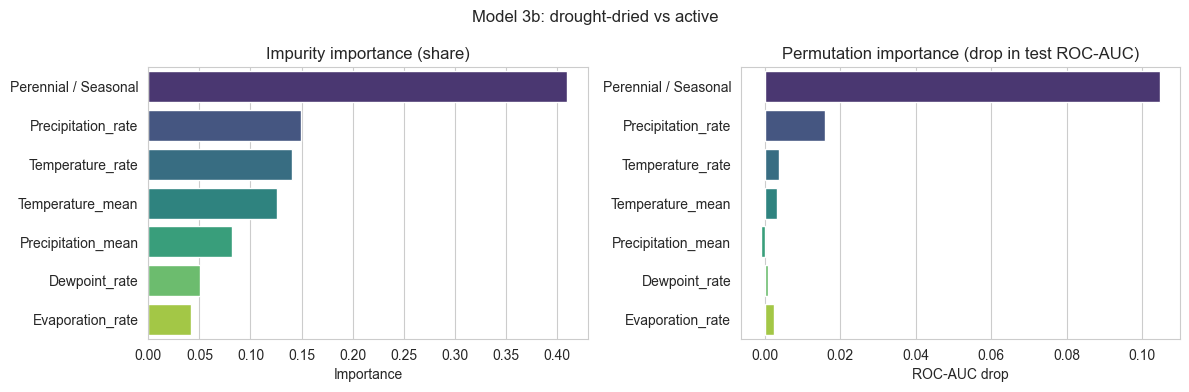

Model 3b: drought-dried vs active  (n = 2786, dried = 226, test = 836)
  test: accuracy 0.793, precision 0.258, recall 0.824, f1 0.393, roc_auc 0.854
  confusion: TN 607  FP 161  FN 12  TP 56
  5-fold CV (shuffled): F1 0.391 +/- 0.029, AUC 0.862 +/- 0.030
  new-area (leave-one-grid-cell-out) AUC 0.752
  VIF dropped: [['Dewpoint_mean', 919.67], ['Evaporation_mean', 76.46]]


Model 3b, climate only  (n = 2786, dried = 226, test = 836)
  test: accuracy 0.666, precision 0.171, recall 0.809, f1 0.283, roc_auc 0.771
  confusion: TN 502  FP 266  FN 13  TP 55
  5-fold CV (shuffled): F1 0.292 +/- 0.029, AUC 0.768 +/- 0.034
  new-area (leave-one-grid-cell-out) AUC 0.543
  VIF dropped: [['Dewpoint_mean', 919.67], ['Evaporation_mean', 76.46]]


Contrast: earthquake-dried vs active  (n = 2789, dried = 229, test = 837)
  test: accuracy 0.718, precision 0.148, recall 0.507, f1 0.229, roc_auc 0.709
  confusion: TN 566  FP 202  FN 34  TP 35
  5-fold CV (shuffled): F1 0.214 +/- 0.014, AUC 0.704 +/- 0.022
  new-area (leave-one-grid-cell-out) AUC 0.571
  VIF dropped: [['Dewpoint_mean', 859.25], ['Evaporation_mean', 75.8]]


,n_springs,n_dried,accuracy,precision,recall,f1,roc_auc,cv_f1_mean,cv_f1_sd,cv_auc_mean,cv_auc_sd,new_area_auc
configuration,,,,,,,,,,,,
Spring type only,3287,727,0.799,0.568,0.385,0.459,0.651,0.480,0.020,0.662,0.011,0.584
Climate only,3287,727,0.621,0.293,0.505,0.370,0.625,0.401,0.023,0.637,0.025,0.527
Model 3 (fixed window),3287,727,0.719,0.405,0.578,0.476,0.748,0.511,0.023,0.760,0.011,0.630
Model 3b: drought-dried vs active,2786,226,0.793,0.258,0.824,0.393,0.854,0.391,0.029,0.862,0.030,0.752
"Model 3b, climate only",2786,226,0.666,0.171,0.809,0.283,0.771,0.292,0.029,0.768,0.034,0.543
Contrast: earthquake-dried vs active,2789,229,0.718,0.148,0.507,0.229,0.709,0.214,0.014,0.704,0.022,0.571


In [4]:
active = data["dried"] == 0
configs = [
    ("cmp_type_only", "Spring type only", np.ones(len(data), bool), ["Perennial / Seasonal"], False),
    ("cmp_climate_only", "Climate only", np.ones(len(data), bool), FEATURE_COLS, False),
    ("model3b_drought", "Model 3b: drought-dried vs active", (active | (data["drying_reason"] == "drought")).values, FEATURES, True),
    ("model3b_drought_climate_only", "Model 3b, climate only", (active | (data["drying_reason"] == "drought")).values, FEATURE_COLS, False),
    ("cmp_earthquake", "Contrast: earthquake-dried vs active", (active | (data["drying_reason"] == "earthquake")).values, FEATURES, False),
]
results = {"model3_final": model3}
for name, title, mask, cols, figs in configs:
    res, _ = run_experiment(name, title, data.loc[mask, cols], data.loc[mask, "dried"].values, make_model3(),
                            groups=groups[mask], new_area=True, make_figures=figs)
    results[name] = res
    print_result(res)

order = ["cmp_type_only", "cmp_climate_only", "model3_final", "model3b_drought", "model3b_drought_climate_only", "cmp_earthquake"]
summary = pd.DataFrame([{"configuration": results[k]["title"], "n_springs": results[k]["n_rows"], "n_dried": results[k]["n_dried"],
                         **results[k]["test"], "cv_f1_mean": results[k]["cv"]["f1_mean"], "cv_f1_sd": results[k]["cv"]["f1_sd"],
                         "cv_auc_mean": results[k]["cv"]["auc_mean"], "cv_auc_sd": results[k]["cv"]["auc_sd"],
                         "new_area_auc": results[k]["new_area_auc"]} for k in order]).set_index("configuration")
summary.round(4).to_csv(TABLES_DIR / "model3_final_summary.csv")
summary.round(3)

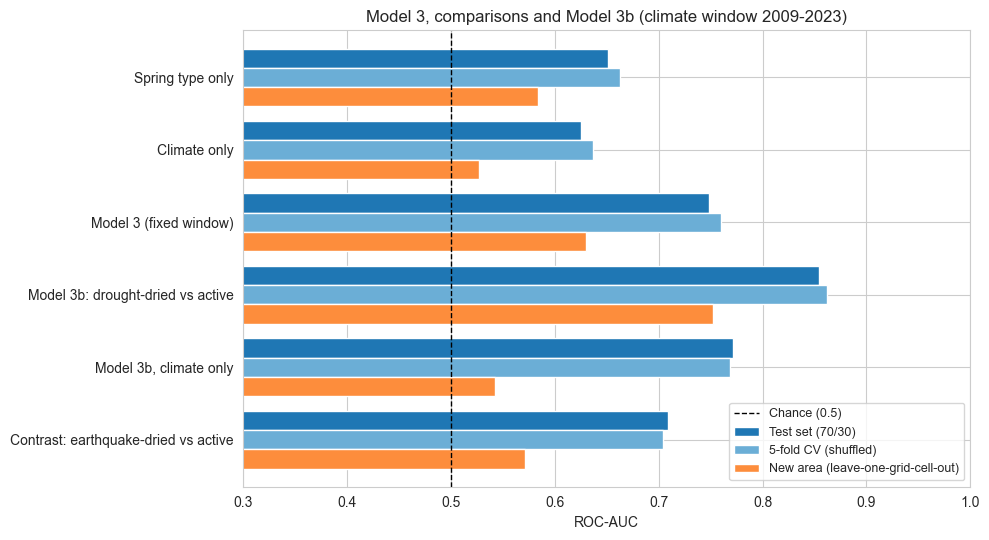

In [5]:
plot = summary[["roc_auc", "cv_auc_mean", "new_area_auc"]].rename(columns={
    "roc_auc": "Test set (70/30)", "cv_auc_mean": "5-fold CV (shuffled)", "new_area_auc": "New area (leave-one-grid-cell-out)"})
ax = plot.plot.barh(figsize=(10, 5.5), width=0.8, color=["#1f77b4", "#6baed6", "#fd8d3c"])
ax.axvline(0.5, color="k", ls="--", lw=1, label="Chance (0.5)")
ax.set_xlim(0.3, 1.0); ax.set_xlabel("ROC-AUC"); ax.set_ylabel(""); ax.invert_yaxis()
ax.set_title(f"Model 3, comparisons and Model 3b (climate window {WINDOW_END - WINDOW_LEN + 1}-{WINDOW_END})")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "model3_comparison.png", dpi=300); plt.show()

## Checks: lookup-table baseline, unshuffled CV, and the Version A leakage diagnostic

In [6]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from spring_drying.evaluation import holdout_metrics

checks = {}
# 1) Lookup table: dried rate of each distinct feature row, learned on the training springs only
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE)
key = lambda d: d.round(9).astype(str).agg("|".join, axis=1)
rate = pd.Series(y_tr).groupby(key(X_tr).values).mean()
p = key(X_te).map(rate).fillna(y_tr.mean()).values
checks["lookup_table_auc"] = float(roc_auc_score(y_te, p))
checks["test_rows_seen_in_train_pct"] = 100 * float(key(X_te).isin(set(key(X_tr))).mean())
checks["n_distinct_rows"] = int(X.round(9).drop_duplicates().shape[0])

# 2) The submitted report's CV: 5 folds in file order (no shuffling)
unshuffled = cross_val_score(make_model3(), X, y, cv=5, scoring="f1")
checks["cv_f1_unshuffled_mean"], checks["cv_f1_unshuffled_sd"] = float(unshuffled.mean()), float(unshuffled.std())
checks["cv_f1_unshuffled_folds"] = [float(v) for v in unshuffled]
checks["dried_pct_by_file_fifth"] = [100 * float(c.mean()) for c in np.array_split(y, 5)]

# 3) Version A leakage diagnostic: the end year of each spring's Version A window as the ONLY input
window_end = data["dried_year"].where(data["dried"] == 1, WINDOW_END)
diag = pd.DataFrame({"window_end_year": window_end, "dried": data["dried"]}).dropna()
d_tr, d_te, dy_tr, dy_te = train_test_split(diag[["window_end_year"]], diag["dried"], test_size=0.3,
                                            stratify=diag["dried"], random_state=RANDOM_STATE)
rf = RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=RANDOM_STATE).fit(d_tr, dy_tr)
checks["leakage_diagnostic"] = {k: float(v) for k, v in holdout_metrics(dy_te, rf.predict(d_te), rf.predict_proba(d_te)[:, 1]).items()}
checks["n_dried_ending_in_survey_year"] = int(((data["dried"] == 1) & (data["dried_year"] == WINDOW_END)).sum())
save_json(checks, "model3_checks.json")
checks

saved C:\Users\kants\OneDrive\Desktop\ME Classes\3rd Sem\Thesis & Project\Python program\results\tables\model3_checks.json


{'lookup_table_auc': 0.7482671406926664,
 'test_rows_seen_in_train_pct': 99.89868287740629,
 'n_distinct_rows': 23,
 'cv_f1_unshuffled_mean': 0.35975314993108354,
 'cv_f1_unshuffled_sd': 0.1059139207705481,
 'cv_f1_unshuffled_folds': [0.3295194508009153,
  0.43333333333333335,
  0.45473684210526316,
  0.16574585635359115,
  0.41543026706231456],
 'dried_pct_by_file_fifth': [20.66869300911854,
  19.45288753799392,
  20.395738203957382,
  11.415525114155251,
  38.660578386605785],
 'leakage_diagnostic': {'accuracy': 0.9939086294416244,
  'precision': 1.0,
  'recall': 0.9723502304147466,
  'f1': 0.985981308411215,
  'roc_auc': 0.9861751152073732},
 'n_dried_ending_in_survey_year': 20}